In [33]:
from datetime import datetime, timedelta
import yfinance as yf
import numpy as np
import pandas as pd
from hurst import compute_Hc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
import seaborn as sns

# Intuition

- Compare stochastic and fractal accuracy to identify extreme or normal market state.
- Institute Hybrid Model which uses stochastic, fractal, and complimentary parameters to accurately predict tommorrow's market direction.

[*********************100%***********************]  1 of 1 completed


Current date:2025-04-23 collected 6364 historical observations

Fractal_RFC Model:
Train Avg Accuracy: 0.6124 ± 0.0512
Test Avg Accuracy: 0.5309 ± 0.0157
Prediction for tomorrow (2025-04-24):
Probability of Up: 0.5236
Direction: Up

Stochastic_RFC Model:
Train Avg Accuracy: 0.6218 ± 0.0380
Test Avg Accuracy: 0.5447 ± 0.0105
Prediction for tomorrow (2025-04-24):
Probability of Up: 0.5379
Direction: Up

Hybrid_RFC Model (Normal Regime):
Train Avg Accuracy: 0.7385 ± 0.0221
Test Avg Accuracy: 0.6902 ± 0.0168
Prediction for tomorrow (2025-04-24):
Probability of Up: 0.5330
Direction: Up

Fractal_XGB Model:
Train Avg Accuracy: 0.6080 ± 0.0467
Test Avg Accuracy: 0.5213 ± 0.0089
Prediction for tomorrow (2025-04-24):
Probability of Up: 0.5368
Direction: Up

Stochastic_XGB Model:
Train Avg Accuracy: 0.5981 ± 0.0292
Test Avg Accuracy: 0.5373 ± 0.0123
Prediction for tomorrow (2025-04-24):
Probability of Up: 0.5225
Direction: Up

Hybrid_XGB Model (Normal Regime):
Train Avg Accuracy: 0.7383 ± 0.0173


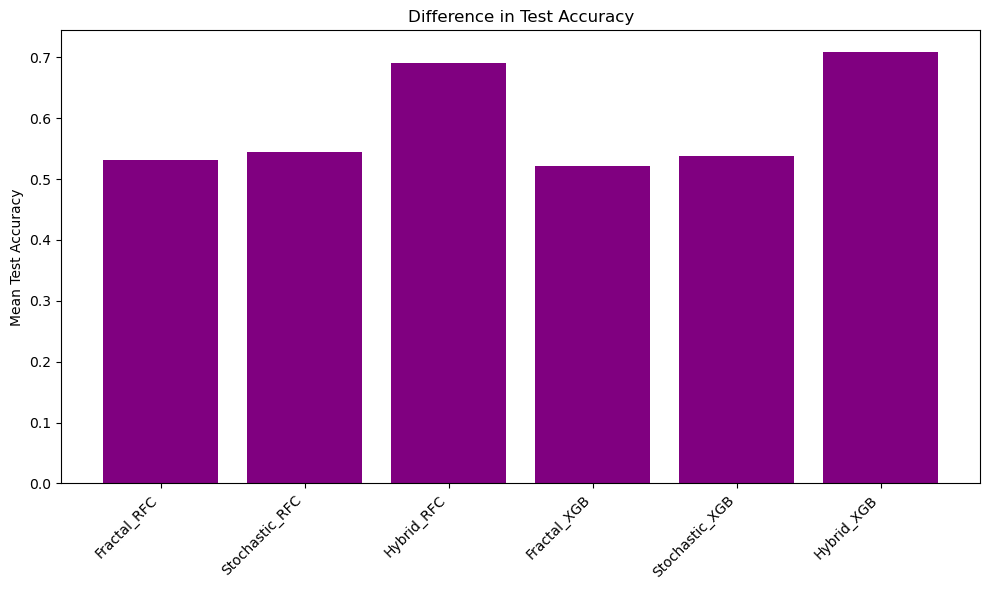

In [ ]:
#loading data and preprocessing
data = yf.download('^GSPC', start='2000-01-01', end=datetime.now().strftime('%Y-%m-%d'))
data = data.dropna()
closing_prices = data['Close'].values.flatten()
volume = data['Volume'].values.flatten()

print(f"Current date:{datetime.now().strftime('%Y-%m-%d')} collected {len(closing_prices)} historical observations")

#converting closing prices into returns for convienence
window = 200
returns = np.diff(closing_prices)/closing_prices[:-1]
aligned_returns = returns[window - 1:]
y = (aligned_returns > 0).astype(int)

#fractal features
hurst_short, hurst_long, volatility = [], [], []

for i in range(window, len(closing_prices)):
    #index of zero just extracts hurst component which is all we need
    short = compute_Hc(closing_prices[i - 100:i], kind='price', simplified=True)[0]
    long = compute_Hc(closing_prices[i - 200:i], kind='price', simplified=True)[0]
    
    hurst_short.append(short)
    hurst_long.append(long)
    volatility.append(np.std(closing_prices[i - 200:i]))

Fractal_df = pd.DataFrame({
    'H_short': hurst_short,
    'H_long': hurst_long,
    'Volatility': volatility
})
Fractal = Fractal_df.values

#stochastic features

def BlackScholesRolling(closing_prices, window):
    log_returns = np.log(pd.Series(closing_prices).pct_change() + 1).dropna()
    mu = log_returns.rolling(window).mean().dropna().values
    sigma = log_returns.rolling(window).std().dropna().values
    return mu, sigma

mu_roll, sigma_roll = BlackScholesRolling(closing_prices, window)

Stochastic_df = pd.DataFrame({
    'mu_roll': mu_roll,
    'sigma_roll': sigma_roll
})
Stochastic = Stochastic_df.values

#Hybrid Features (many new features that provide synergy between fractal and stochastic methods)

returns_shifted = returns[window - 1:]
lag1, lag5 = np.roll(returns_shifted, 1), np.roll(returns_shifted, 5)
lag1[0], lag5[:5] = 0, 0

rolling = pd.Series(closing_prices).rolling
rollavg10 = rolling(10).mean().values[window:]
rollavg50 = rolling(50).mean().values[window:]
trend = (rollavg10 > rollavg50).astype(int)

#emw standing for exponential weighted moving average with 14 day window (span)
rsi = pd.Series(returns).ewm(span=14).mean().values[window - 1:]

Hybrid = np.column_stack((Fractal, Stochastic, lag1, lag5, trend, rsi))

#normalization
scaler = StandardScaler()
Fractal = scaler.fit_transform(Fractal)
Stochastic = scaler.fit_transform(Stochastic)
Hybrid = scaler.fit_transform(Hybrid)

#
time_series_split = TimeSeriesSplit(n_splits=5)

models = {
        'Fractal_RFC': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=3, min_samples_split=2, random_state=10),
        'Stochastic_RFC': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=3, min_samples_split=2, random_state=10),
        'Hybrid_RFC': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=3, min_samples_split=2, random_state=10),
        'Fractal_XGB': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=10),
        'Stochastic_XGB': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=10),
        'Hybrid_XGB': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss', random_state=10)
}

featureMatrixMap = {
        'Fractal_RFC': Fractal,
        'Fractal_XGB': Fractal,
        'Stochastic_RFC': Stochastic,
        'Stochastic_XGB': Stochastic,
        'Hybrid_RFC': Hybrid,
        'Hybrid_XGB': Hybrid
}

results = {
    model_name: {
            'train_scores': [],
            'test_scores': [],
            'daily_prediction': None,
            'pred_direction': None
        }
        for model_name in models
}

for model_name, model, in models.items():
    X = featureMatrixMap[model_name]
    
    for trainIndex, testIndex in time_series_split.split(X):
        X_train, X_test = X[trainIndex], X[testIndex]
        y_train, y_test = y[trainIndex], y[testIndex]
        model.fit(X_train, y_train)
        results[model_name]['train_scores'].append(accuracy_score(y_train, model.predict(X_train)))
        results[model_name]['test_scores'].append(accuracy_score(y_test, model.predict(X_test)))
    
    #fits the model on all of the data aside from current day (which is either to be predicted or does not have a closing price in relevant timeframe)
    model.fit(X[:-1], y[:-1])
    #need to convert to 2d array for inference methods
    X_today = X[-1].reshape(1,-1)
    results[model_name]['probability'] = model.predict_proba(X_today)[0,1]
    results[model_name]['pred_direction'] = model.predict(X_today)[0]
    
#Determine Extreme or Normal Regime based on model preformance
fractal_performance = np.mean(results['Fractal_XGB']['test_scores'])
stochastic_performance = np.mean(results['Stochastic_XGB']['test_scores'])

if fractal_performance > stochastic_performance:
    regime = "Extreme"
elif stochastic_performance > fractal_performance:
    regime = "Normal"
else: 
    regime = "Uncertain"
    
tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')

for model_name in models:
    model_label = f"{model_name} Model{f' ({regime} Regime)' if 'Hybrid' in model_name else ''}"
    print(f"\n{model_label}:")
    print(f"Train Avg Accuracy: {np.mean(results[model_name]['train_scores']):.4f} ± {np.std(results[model_name]['train_scores']):.4f}")
    print(f"Test Avg Accuracy: {np.mean(results[model_name]['test_scores']):.4f} ± {np.std(results[model_name]['test_scores']):.4f}")
    print(f"Prediction for tomorrow ({tomorrow}):")
    print(f"Probability of Up: {results[model_name]['probability']:.4f}")
    print(f"Direction: {'Up' if results[model_name]['pred_direction'] == 1 else 'Down'}")

    if 'Hybrid_XGB' in model_name:
        print("Feature Importances:")
        feature_names = ['H_short', 'H_long', 'Volatility', 'mu_roll', 'sigma_roll', 'Lag1', 'Lag5', 'Trend', 'RSI']
        importances = models[model_name].feature_importances_
        for fname, imp in zip(feature_names, importances):
            print(f"{fname}: {imp:.4f}")

model_names = [name for name in models]
test_means = [np.mean(results[name]['test_scores']) for name in models]

plt.figure(figsize=(10, 6))
plt.bar(model_names, test_means, color='purple')
plt.ylabel('Mean Test Accuracy')
plt.title('Difference in Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



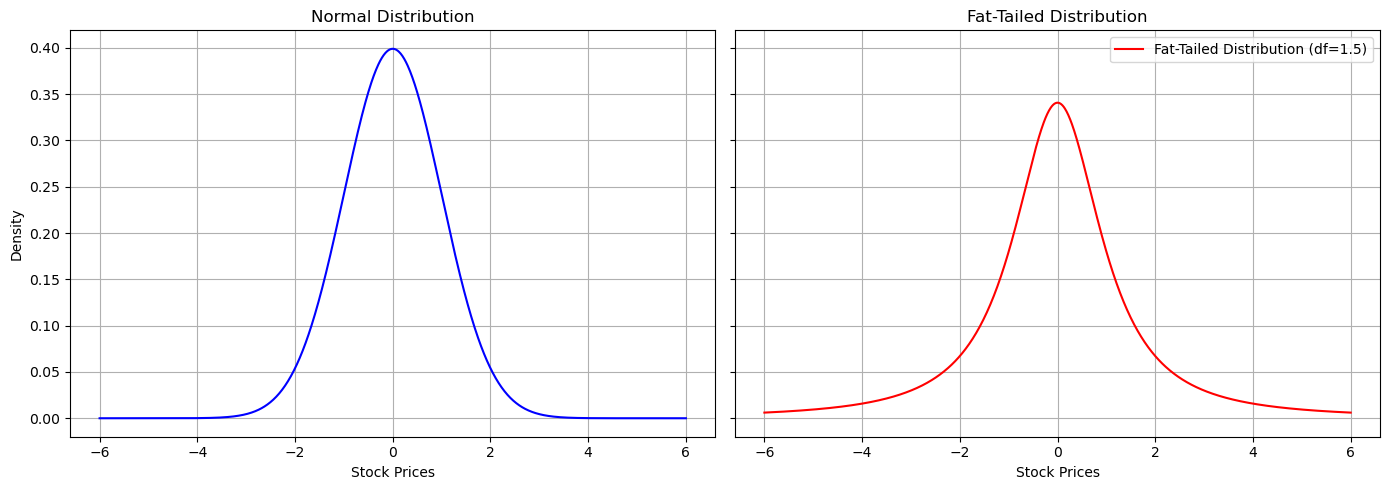

In [ ]:
x = np.linspace(-6, 6, 1000)
normal_pdf = norm.pdf(x, loc=0, scale=1)
t_pdf_heavy = t.pdf(x, df=1.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(x, normal_pdf, label='Normal Distribution', color='blue')
axes[0].set_title('Normal Distribution')
axes[0].set_xlabel('Stock Prices')
axes[0].set_ylabel('Density')
axes[0].grid(True)

axes[1].plot(x, t_pdf_heavy, label='Fat-Tailed Distribution (df=1.5)', color='red')
axes[1].set_title('Fat-Tailed Distribution')
axes[1].set_xlabel('Stock Prices')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed
C:\Users\reyno\AppData\Local\Temp\ipykernel_21448\3088499914.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=params, orient='h', palette='viridis')


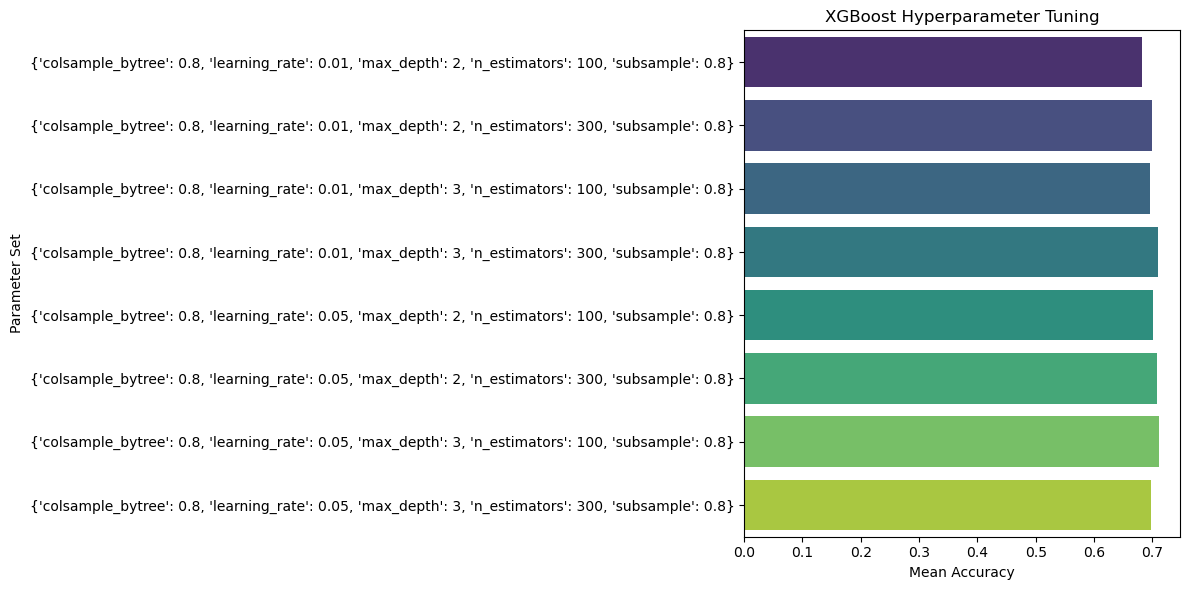

C:\Users\reyno\AppData\Local\Temp\ipykernel_21448\3088499914.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=params, orient='h', palette='viridis')


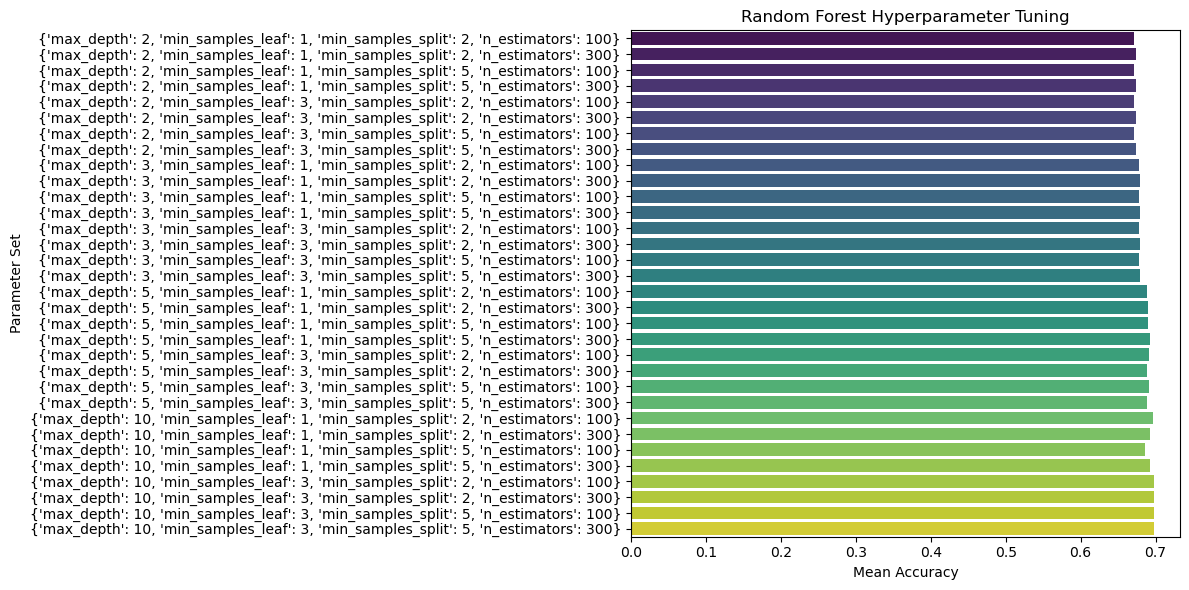

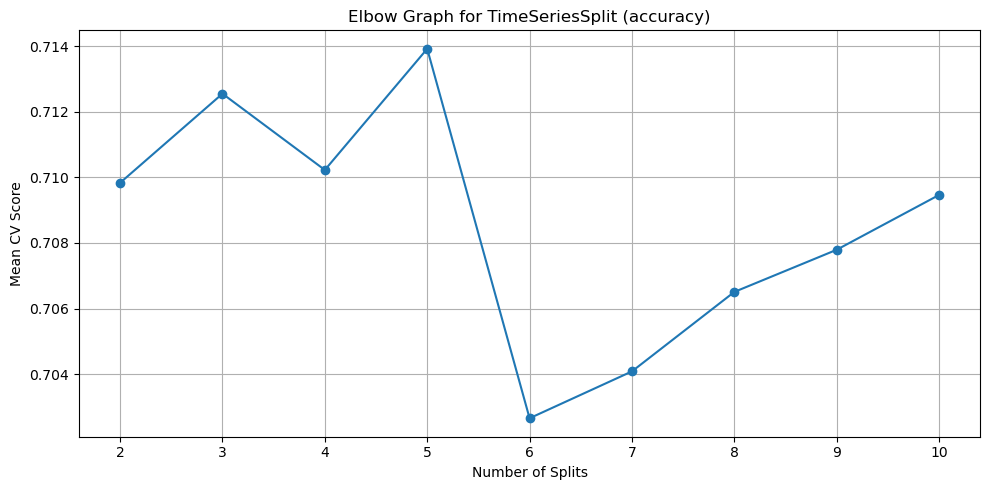

In [ ]:
# Load and preprocess data
data = yf.download('^GSPC', start='2000-01-01', end=datetime.now().strftime('%Y-%m-%d'))
data = data.dropna()
closing_prices = data['Close'].values.flatten()

# Returns and labels
window = 200
returns = np.diff(closing_prices) / closing_prices[:-1]
y = (returns[window - 1:] > 0).astype(int)

# Fractal features
hurst_short, hurst_long, volatility = [], [], []
for i in range(window, len(closing_prices)):
    short = compute_Hc(closing_prices[i - 100:i], kind='price', simplified=True)[0]
    long = compute_Hc(closing_prices[i - 200:i], kind='price', simplified=True)[0]
    hurst_short.append(short)
    hurst_long.append(long)
    volatility.append(np.std(closing_prices[i - 200:i]))

Fractal = np.column_stack((hurst_short, hurst_long, volatility))

# Stochastic features
def BlackScholesRolling(closing_prices, window):
    log_returns = np.log(pd.Series(closing_prices).pct_change() + 1).dropna()
    mu = log_returns.rolling(window).mean().dropna().values
    sigma = log_returns.rolling(window).std().dropna().values
    return mu, sigma

mu_roll, sigma_roll = BlackScholesRolling(closing_prices, window)
Stochastic = np.column_stack((mu_roll, sigma_roll))

# Hybrid features
returns_shifted = returns[window - 1:]
lag1, lag5 = np.roll(returns_shifted, 1), np.roll(returns_shifted, 5)
lag1[0], lag5[:5] = 0, 0
rollavg10 = pd.Series(closing_prices).rolling(10).mean().values[window:]
rollavg50 = pd.Series(closing_prices).rolling(50).mean().values[window:]
trend = (rollavg10 > rollavg50).astype(int)
rsi = pd.Series(returns).ewm(span=14).mean().values[window - 1:]
Hybrid = np.column_stack((Fractal, Stochastic, lag1, lag5, trend, rsi))

# Normalize
scaler = StandardScaler()
Hybrid = scaler.fit_transform(Hybrid)

# Hyperparameter tuning
time_series_split = TimeSeriesSplit(n_splits=5)

param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=time_series_split, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search_xgb.fit(Hybrid[:-1], y[:-1])
best_model_xgb = grid_search_xgb.best_estimator_

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [2, 3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}
rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=time_series_split, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search_rf.fit(Hybrid[:-1], y[:-1])
best_model_rf = grid_search_rf.best_estimator_

def plot_cv_scores(cv_results, title):
    scores = cv_results['mean_test_score']
    params = [str(p) for p in cv_results['params']]
    plt.figure(figsize=(12, 6))
    sns.barplot(x=scores, y=params, orient='h', palette='viridis')
    plt.title(title)
    plt.xlabel('Mean Accuracy')
    plt.ylabel('Parameter Set')
    plt.tight_layout()
    plt.show()

plot_cv_scores(grid_search_xgb.cv_results_, "XGBoost Hyperparameter Tuning")
plot_cv_scores(grid_search_rf.cv_results_, "Random Forest Hyperparameter Tuning")

def evaluate_n_splits(X, y, model, max_splits=10, scoring='accuracy'):
    scores = []
    splits = list(range(2, max_splits + 1))
    for n in splits:
        tscv = TimeSeriesSplit(n_splits=n)
        score = cross_val_score(model, X, y, cv=time_series_split, scoring=scoring)
        scores.append(np.mean(score))

    plt.figure(figsize=(10, 5))
    plt.plot(splits, scores, marker='o')
    plt.title(f'Elbow Graph for TimeSeriesSplit ({scoring})')
    plt.xlabel('Number of Splits')
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

evaluate_n_splits(Hybrid[:-1], y[:-1], best_model_xgb, max_splits=10, scoring='accuracy')